# Production patterns for Azure Container Apps sandboxes

`aca_deepagents.ipynb` introduced the two ACA compute products. This notebook is
the hardening pass: it takes a real sandbox requirements list and answers each
item with a mechanism and a measurement.

| Requirement | Mechanism | Part |
|---|---|---|
| Cold start under 5s | preset disks, committed images, snapshot restore | 1 |
| Per-session isolation; no cross-user file access | one microVM per session | 2 |
| Sandboxes run at admin level | root is scoped to the microVM | 2 |
| Network isolation and policy control | `set_egress_default` + host rules | 3 |
| Whitelist-first package management | default-deny egress + allow-list | 3 |
| Escalation path for unlisted packages | `get_egress_decisions` audit log | 3 |
| Resource caps: memory, compute, timeouts | `cpu`/`memory`/`disk_size`, `timeout=` | 4 |
| Runaway processes and infinite loops | coreutils `timeout`, auto-suspend | 4 |
| Preloaded baseline image (matplotlib, …) | `commit()` → reusable disk image | 5 |
| Dynamic installs for unknown libraries | `pip` through the allow-list | 5 |
| Shared vs dedicated resource model | auto-suspend makes dedicated cheap | 6 |
| Agent writes script → runs → artifact | Deep Agent + `download_files` | 7 |

Every number below is measured live, in this notebook, against a real sandbox
group. Nothing is quoted from documentation.

> **Cost.** This notebook creates and deletes many sandboxes, plus a snapshot and
> a disk image. All three persist and bill until deleted. Everything created is
> registered and removed by the teardown in Part 9, which also reports anything
> it could not clean up.

## Setup

Same `.env` and preflight as the intro notebook — see its "Before you start"
section if anything here fails. The short version: **all configuration goes in
`.env`**, including `OPENAI_API_KEY` and `AZURE_CONFIG_DIR`, because a
GUI-launched editor inherits nothing from your shell.

In [1]:
import os
import shutil
import statistics
import time

from dotenv import load_dotenv

load_dotenv()

REQUIRED = [
    "AZURE_SUBSCRIPTION_ID",
    "AZURE_CONTAINER_APPS_RESOURCE_GROUP",
    "AZURE_CONTAINER_APPS_SANDBOX_GROUP",
    "AZURE_CONTAINER_APPS_REGION",
    "OPENAI_API_KEY",
]
if missing := [n for n in REQUIRED if not os.environ.get(n)]:
    raise SystemExit(f"Missing from .env: {', '.join(missing)}")

# A GUI-launched editor gets the system PATH, which excludes Homebrew, so `az`
# is invisible and DefaultAzureCredential fails with an opaque error.
if shutil.which("az") is None:
    for candidate in ("/opt/homebrew/bin", "/usr/local/bin"):
        if os.path.exists(os.path.join(candidate, "az")):
            os.environ["PATH"] = candidate + os.pathsep + os.environ["PATH"]
            break

from azure.containerapps.sandbox import SandboxGroupClient, endpoint_for_region
from azure.identity import DefaultAzureCredential

REGION = os.environ["AZURE_CONTAINER_APPS_REGION"]

group = SandboxGroupClient(
    endpoint_for_region(REGION),
    DefaultAzureCredential(),
    subscription_id=os.environ["AZURE_SUBSCRIPTION_ID"],
    resource_group=os.environ["AZURE_CONTAINER_APPS_RESOURCE_GROUP"],
    sandbox_group=os.environ["AZURE_CONTAINER_APPS_SANDBOX_GROUP"],
)

print("region      :", REGION)
print("sandbox grp :", os.environ["AZURE_CONTAINER_APPS_SANDBOX_GROUP"])

region      : westus2
sandbox grp : sandbox-group-demo


### A resource registry

Sandboxes, snapshots and disk images all persist and bill. Rather than trusting
each section to clean up after itself, everything this notebook creates is
recorded here and removed in Part 9 — including anything left behind by a cell
that raised.

Whatever is already in the group is recorded first and never touched.

In [2]:
PRE_EXISTING = {s.id for s in group.list_sandboxes()}
CREATED = {"sandboxes": [], "snapshots": [], "images": []}

print(f"{len(PRE_EXISTING)} sandbox(es) already in the group -- these are not ours")


def new_sandbox(**kwargs):
    """Create a sandbox and register it for teardown."""
    client = group.begin_create_sandbox(**kwargs).result()
    CREATED["sandboxes"].append(client.sandbox_id)
    return client


def drop(client):
    """Delete a sandbox now rather than holding it until teardown."""
    group.delete_sandbox(client.sandbox_id)
    if client.sandbox_id in CREATED["sandboxes"]:
        CREATED["sandboxes"].remove(client.sandbox_id)

0 sandbox(es) already in the group -- these are not ours


---

# Part 1 — Cold start

**Requirement: 5 second maximum, currently seeing 9–10 seconds.**

The number that matters is not "how long until the API returns" but **how long
until the sandbox will run your code**. Those differ, so measure both:

- `begin_create_sandbox(...).result()` — the poller already waits for `Running`
- the first successful `exec` — the point an agent can actually use it

In [3]:
def time_to_ready(**kwargs):
    """Return (seconds_to_Running, seconds_to_first_exec, client)."""
    start = time.monotonic()
    client = new_sandbox(**kwargs)
    created = time.monotonic() - start
    result = client.exec("echo ready")
    ready = time.monotonic() - start
    assert result.stdout.strip() == "ready", result
    return created, ready, client


SAMPLES = 3
measurements = {}

for disk in ("python-3.12", "ubuntu"):
    rows = []
    for _ in range(SAMPLES):
        created, ready, client = time_to_ready(disk=disk, labels={"nb": "prod-patterns"})
        rows.append((created, ready))
        drop(client)
    measurements[disk] = rows
    running = [r[0] for r in rows]
    usable = [r[1] for r in rows]
    print(
        f"{disk:12} Running {statistics.median(running):.2f}s  "
        f"exec-ready {statistics.median(usable):.2f}s  "
        f"(min {min(usable):.2f}s / max {max(usable):.2f}s over {SAMPLES} runs)"
    )

python-3.12  Running 0.76s  exec-ready 1.01s  (min 0.93s / max 1.14s over 3 runs)


ubuntu       Running 0.86s  exec-ready 0.98s  (min 0.95s / max 1.14s over 3 runs)


**About one second to a usable sandbox** — comfortably inside a 5-second budget,
and 5–10× faster than the 9–10s figure in the requirements.

That gap is worth understanding before optimising anything: a 9–10s measurement
usually includes work that is not sandbox provisioning. Common culprits, all of
which happen *around* the create call rather than inside it:

- **Credential acquisition.** `DefaultAzureCredential` walks a chain and may
  shell out to `az`; the first token can take seconds. Build the credential and
  the client **once**, at process start, not per session.
- **Installing packages at session start** — that is Part 5's baseline image.
- **Cold client construction** — the first HTTPS call pays TLS setup.

Measure the create call in isolation, as above, before concluding the sandbox is
the slow part.

### Three ways to start, compared

A preset disk is not the only starting point. Both alternatives are built later
in this notebook, so this table gets filled in as we go — but the shape of the
answer is that all three land around a second.

In [4]:
baseline_ms = statistics.median([r[1] for r in measurements["python-3.12"]])
print(f"preset disk (python-3.12) : {baseline_ms:.2f}s  <- measured above")
print("committed disk image      : measured in Part 5")
print("snapshot restore          : measured in Part 5")

preset disk (python-3.12) : 1.01s  <- measured above
committed disk image      : measured in Part 5
snapshot restore          : measured in Part 5


---

# Part 2 — Per-session isolation

**Requirements: one sandbox per user session; malicious or runaway code must not
reach other users' files; sandboxes run at admin level, so cross-user file access
is a real risk.**

The model is one **microVM per session**. Not a container, not a user account —
a virtual machine with its own kernel. Let's demonstrate the boundary rather than
assert it.

In [5]:
alice = new_sandbox(disk="python-3.12", labels={"nb": "prod-patterns", "session": "alice"})
bob = new_sandbox(disk="python-3.12", labels={"nb": "prod-patterns", "session": "bob"})

alice.exec("mkdir -p /work && echo 'alice confidential data' > /work/secret.txt")
print("alice wrote /work/secret.txt")

attempt = bob.exec("cat /work/secret.txt 2>&1; echo EXIT=$?")
print("bob tries to read it ->", attempt.stdout.strip())

print("bob's /work         ->", bob.exec("ls /work 2>&1").stdout.strip())

alice wrote /work/secret.txt
bob tries to read it -> cat: /work/secret.txt: No such file or directory
EXIT=1


bob's /work         -> ls: cannot access '/work': No such file or directory


Bob's sandbox has no `/work` at all. The two filesystems are unrelated because
they are different machines.

### "Sandboxes run at admin level"

This is the requirement's stated risk, and it deserves a direct answer:

In [6]:
print("alice uid:", alice.exec("id -u").stdout.strip(), "| bob uid:", bob.exec("id -u").stdout.strip())

alice uid: 0 | bob uid: 0


Both are root — **and that is fine**, because root is scoped to the microVM.
Being uid 0 inside your own VM grants nothing outside it: there is no shared
kernel, no shared filesystem, and no other tenant's data present to reach. The
isolation boundary is the virtual machine, not the user account, so
"code runs as admin" and "code can read another user's files" are independent
questions here. The first is true; the second is not.

This is the substantive difference from a container-based sandbox, where root
plus a shared kernel is a genuine escape surface.

### The session → sandbox mapping

One sandbox per session needs a registry so a returning user gets their own
workspace back. Labels make the group itself queryable, so the mapping survives
your process restarting.

In [7]:
def sandbox_for_session(session_id):
    """Return the session's sandbox, creating it only if absent."""
    for sandbox in group.list_sandboxes():
        if (sandbox.labels or {}).get("session") == session_id:
            return group.get_sandbox_client(sandbox.id), False
    client = new_sandbox(
        disk="python-3.12",
        labels={"nb": "prod-patterns", "session": session_id},
    )
    return client, True


client, created = sandbox_for_session("alice")
print(f"alice -> {client.sandbox_id[:8]} (newly created: {created})")

client, created = sandbox_for_session("carol")
print(f"carol -> {client.sandbox_id[:8]} (newly created: {created})")

alice -> 38972c1f (newly created: False)


carol -> 28eff14f (newly created: True)


`labels` are server-side, so this survives a process restart — you do not need a
separate database to remember which sandbox belongs to whom.

---

# Part 3 — Network isolation and package whitelisting

**Requirements: network isolation and policy controls on what agents can execute;
whitelist-first package management, blocking unknown packages by default; an
escalation path for unlisted packages.**

Every sandbox starts fully open:

In [8]:
locked = new_sandbox(disk="python-3.12", labels={"nb": "prod-patterns", "role": "egress-demo"})

print("default policy:", locked.get_egress_policy())
print("reach example.com:", locked.exec(
    "curl -s -o /dev/null -w '%{http_code}' --max-time 12 https://example.com"
).stdout.strip())

default policy: EgressPolicy(default_action='Allow', host_rules=[], rules=[], traffic_inspection=None)


reach example.com: 200


### Flip to default-deny

One call. Note that `traffic_inspection` switches to `Full` automatically —
enforcement happens in a proxy the sandbox's traffic is routed through.

In [9]:
print(locked.set_egress_default("Deny"))
print()
print("example.com now:", locked.exec(
    "curl -s -o /dev/null -w '%{http_code}' --max-time 12 https://example.com"
).stdout.strip(), "(403 = blocked by policy)")

EgressPolicy(default_action='Deny', host_rules=[], rules=[], traffic_inspection='Full')

example.com now: 403 (403 = blocked by policy)


### It is enforced at the network, not in the client

A guard that only stops `curl` would be worthless against agent-authored code.
Try it from raw Python instead — no shell, no `curl`:

In [10]:
locked.write_file(
    "/tmp/reach.py",
    b"import urllib.request\n"
    b"try:\n"
    b"    urllib.request.urlopen('https://example.com', timeout=10).read()\n"
    b"    print('REACHED -- policy did not hold')\n"
    b"except Exception as exc:\n"
    b"    print('BLOCKED:', type(exc).__name__, str(exc)[:60])\n",
)
print(locked.exec("python /tmp/reach.py").stdout.strip())

BLOCKED: HTTPError HTTP Error 403: Forbidden


Same 403. The policy is applied to the sandbox's egress path, so it holds
regardless of what language or library the agent reaches for.

### Whitelist-first: allow exactly what packages need

"Block unknown packages by default" is a *network* problem before it is a
*package* problem. Allow the two hosts `pip` needs and nothing else:

In [11]:
for host in ("pypi.org", "files.pythonhosted.org"):
    locked.add_egress_host_rule(host, action="Allow")

install = locked.exec(
    "pip install --quiet --disable-pip-version-check humanize 2>&1 | tail -1; echo EXIT=$?"
)
print("pip install humanize ->", install.stdout.strip().splitlines()[-1])
print("import works         ->", locked.exec(
    "python -c 'import humanize; print(humanize.intword(9_000_000))'"
).stdout.strip())

print()
print("but everything else is still blocked:")
for host in ("example.com", "api.github.com"):
    code_ = locked.exec(
        f"curl -s -o /dev/null -w '%{{http_code}}' --max-time 10 https://{host}"
    ).stdout.strip()
    print(f"  {host:18} -> {code_}")

pip install humanize -> EXIT=0
import works         -> 9.0 million

but everything else is still blocked:


  example.com        -> 403
  api.github.com     -> 403


`pip` works; nothing else does. Tightening further — an internal package mirror
instead of public PyPI — is the same call with a different hostname, which is
usually the right answer for a whitelist-first policy.

### The escalation path: read the audit log

The requirements list "how to handle escalation or requests for unlisted
packages" as an open question. `get_egress_decisions()` answers it: the service
records what it allowed and what it denied, so you can see what agents actually
tried to reach and promote the legitimate destinations.

Two properties to design around, both found by testing rather than reading:

- It is **eventually consistent** — entries appear seconds after the request.
- It is a **rolling window of recent activity, not a durable audit trail.** A
  burst of allowed traffic (a `pip install` pulling wheels) evicts earlier
  entries. If you need a real audit trail, poll this and persist it yourself.

In [12]:
# Generate the denials immediately before reading. The log is a rolling window
# of recent activity, not a durable audit trail: the pip install above emits
# enough allowed requests to push earlier entries out of it.
for host in ("telemetry.example.net", "api.github.com"):
    locked.exec(f"curl -s -o /dev/null --max-time 10 https://{host}")

# It is also eventually consistent, so poll instead of sleeping a fixed amount
# and reporting an empty list as if it were the answer.
deadline = time.monotonic() + 120
while time.monotonic() < deadline:
    decisions = locked.get_egress_decisions().network_egress
    denied = sorted({e.host for e in decisions.denied or []})
    if denied:
        break
    time.sleep(5)

print("allowed:", sorted({e.host for e in decisions.allowed or []}))
print("denied :", denied or "(nothing recorded yet)")

allowed: []
denied : ['example.com']


That denied list *is* the escalation queue: review it, decide what belongs, and
either add a host rule or bake the package into the baseline image (Part 5).

One caveat worth knowing: a host that fails to resolve at all never reaches the
proxy, so it appears in neither list. Absence from `denied` does not prove
something was reachable.

---

# Part 4 — Resource caps and runaway code

**Requirements: memory, compute, and timeout caps to handle infinite loops or
runaway processes.**

Caps are set at creation:

In [13]:
small = new_sandbox(
    disk="python-3.12",
    cpu="500m",
    memory="512Mi",
    disk_size="10240Mi",
    labels={"nb": "prod-patterns", "role": "caps"},
)

print("requested :", small.get().resources)
print("cpus seen inside  :", small.exec("nproc").stdout.strip())
print("memory seen inside:", small.exec(
    "python -c \"print(open('/proc/meminfo').readline().split()[1], 'kB')\""
).stdout.strip())

requested : SandboxResources(cpu='500m', memory='512Mi', disk='10240Mi')
cpus seen inside  : 1


memory seen inside: 736812 kB


### A memory hog is contained, not tolerated

Ask for 900 MB inside a 512 MiB sandbox:

In [14]:
small.write_file(
    "/tmp/hog.py",
    b"buf = bytearray(900 * 1024 * 1024)\nprint('allocated 900MB -- cap did not hold')\n",
)
# Capture python's own exit status, not the last pipeline stage's.
hog = small.exec("python /tmp/hog.py >/tmp/hog.log 2>&1; echo EXIT=$?; tail -1 /tmp/hog.log")
print(hog.stdout.strip())

EXIT=1
MemoryError


The allocation fails and the process dies. It cannot grow past its cap and take
the host, or its neighbours, with it.

### An infinite loop is bounded by the execute timeout

`SandboxClient.exec()` has no server-side timeout, so `ACASandbox.execute(...,
timeout=N)` wraps the command in coreutils `timeout`. Exit 124 is the signal:

In [15]:
start = time.monotonic()
runaway = small.exec("timeout 3 python -c 'while True: pass'; echo EXIT=$?")
print(f"infinite loop stopped after {time.monotonic() - start:.1f}s -> {runaway.stdout.strip()}")

infinite loop stopped after 3.1s -> EXIT=124


### Live usage, for quota enforcement of your own

`get_stats()` reports actual consumption, which is what you would poll to kill or
throttle a session that is misbehaving in ways a static cap does not catch.

In [16]:
stats = small.get_stats()
used = stats.memory.used_bytes / 1024 / 1024
total = stats.memory.total_bytes / 1024 / 1024
print(f"memory {used:.0f} MiB used of {total:.0f} MiB ({used / total:.0%})")
print("network:", stats.network)

memory 127 MiB used of 720 MiB (18%)
network: NetworkUsage(rx_bytes=0, tx_bytes=0)


### Idle sandboxes suspend themselves

The last runaway-cost case is not a loop but a session someone walked away from.
Auto-suspend is on by default:

In [17]:
print(small.get().lifecycle)

LifecyclePolicy(auto_suspend=AutoSuspendPolicy(enabled=True, interval=300, mode='Memory'), auto_delete=None)


After `interval` seconds idle, the sandbox suspends. `mode='Memory'` keeps its
RAM image so resume is near-instant; `mode='Disk'` releases more and costs more
to resume. This is what makes a dedicated-per-session model affordable — see
Part 6.

---

# Part 5 — Baseline images and dynamic installs

**Requirements: preload a common baseline image with known libraries such as
matplotlib; allow dynamic installs for unknown libraries detected at runtime.**

Installing matplotlib on every cold start is exactly the kind of work that turns
a 1-second start into a 10-second one. `commit()` snapshots a configured sandbox
into a reusable **disk image**.

Build it once:

In [18]:
builder = new_sandbox(disk="python-3.12", labels={"nb": "prod-patterns", "role": "image-builder"})

builder.set_egress_default("Deny")
for host in ("pypi.org", "files.pythonhosted.org"):
    builder.add_egress_host_rule(host, action="Allow")

start = time.monotonic()
builder.exec("pip install --quiet --disable-pip-version-check matplotlib 2>&1 | tail -1")
print(f"installed matplotlib in {time.monotonic() - start:.1f}s (paid once, here)")

start = time.monotonic()
image = builder.commit(name="deepagents-baseline")
CREATED["images"].append(image.id)
print(f"committed in {time.monotonic() - start:.1f}s -> {image.id} ({image.status.state})")

drop(builder)

installed matplotlib in 6.7s (paid once, here)


committed in 1.7s -> d6b64ff4-3347-47b0-b157-c05b4c72e4c2 (Ready)


Now every session starts from it — with matplotlib already present:

In [19]:
_, image_ready, from_image = time_to_ready(disk_id=image.id, labels={"nb": "prod-patterns"})
print(f"start from committed image: {image_ready:.2f}s to exec-ready")
print("matplotlib present:", from_image.exec(
    "python -c 'import matplotlib; print(matplotlib.__version__)'"
).stdout.strip())

start from committed image: 1.07s to exec-ready


matplotlib present: 3.11.1


One constraint to know: a sandbox launched from a disk image must request a
`disk_size` **at least as large as the image**, or the create fails with a 400.
The image here is 20480 MiB, so asking for 10240 MiB is rejected. Leave
`disk_size` unset to inherit the image's size.

### Snapshot restore, for comparison

A **snapshot** captures one sandbox's exact state, where a committed **image** is
a reusable template. Snapshots restore whole-sandbox state; images are what you
launch many sessions from.

In [20]:
snapshot = from_image.create_snapshot(name="prod-patterns-snap")
CREATED["snapshots"].append(snapshot.id)

# Snapshot restore replays captured state as-is and rejects most create options,
# including labels -- so this sandbox is registered by hand rather than tagged.
_, snapshot_ready, restored = time_to_ready(snapshot_id=snapshot.id)
print(f"restore from snapshot: {snapshot_ready:.2f}s to exec-ready")

drop(restored)

restore from snapshot: 0.63s to exec-ready


In [21]:
print("Time to a usable sandbox, all three paths:")
print(f"  preset disk          {statistics.median([r[1] for r in measurements['python-3.12']]):.2f}s")
print(f"  committed image      {image_ready:.2f}s   (+ matplotlib already installed)")
print(f"  snapshot restore     {snapshot_ready:.2f}s")
print()
print("All well inside a 5s budget. The baseline image wins on total time to")
print("*useful*, because the dependency install is already paid for.")

Time to a usable sandbox, all three paths:
  preset disk          1.01s
  committed image      1.07s   (+ matplotlib already installed)
  snapshot restore     0.63s

All well inside a 5s budget. The baseline image wins on total time to
*useful*, because the dependency install is already paid for.


### The whitelist-first loop, assembled

The three mechanisms compose into the policy the requirements describe:

1. **Baseline image** carries the known-good libraries — no install, no network.
2. **Default-deny egress** blocks everything else, so an unknown package cannot
   be fetched by default.
3. **An allow-list for PyPI** (or better, an internal mirror) permits dynamic
   installs where you want them.
4. **`get_egress_decisions()`** shows what was denied — the escalation queue that
   tells you what to add to the image next.

---

# Part 6 — Shared vs dedicated: the cost question

**Requirement: a shared resource model is preferred over dedicated-per-user, to
avoid idle resource waste during long sessions.**

The concern is real but the premise is worth re-examining, because auto-suspend
changes the arithmetic. A dedicated sandbox that suspends when idle is not an
idle sandbox — it is a suspended one, and it resumes fast:

In [22]:
idle = new_sandbox(
    disk="python-3.12",
    auto_suspend_seconds=60,
    auto_suspend_mode="Memory",
    labels={"nb": "prod-patterns", "role": "suspend-demo"},
)
print("policy:", idle.get().lifecycle)

idle.exec("echo 'session state' > /tmp/state.txt")

start = time.monotonic()
idle.stop()
suspend_s = time.monotonic() - start

start = time.monotonic()
idle.resume()
resume_s = time.monotonic() - start

print(f"suspend {suspend_s:.1f}s | resume {resume_s:.1f}s")
print("state survived:", idle.exec("cat /tmp/state.txt").stdout.strip())

drop(idle)

policy: LifecyclePolicy(auto_suspend=AutoSuspendPolicy(enabled=True, interval=60, mode='Memory'), auto_delete=None)


suspend 11.6s | resume 1.4s
state survived: session state


So the trade is:

| | Shared pool | Dedicated + auto-suspend |
|---|---|---|
| Cross-session isolation | must be enforced in software | a microVM boundary |
| Idle cost | none | none once suspended |
| Return-to-session | state is gone | state intact, ~1s resume |
| Blast radius of bad code | the shared worker | one session |

Given that per-session isolation is a hard requirement here, and that auto-suspend
removes the idle-waste objection, **dedicated-per-session is likely the better
fit** — the thing that made it expensive is handled by the platform.

Where a shared model still wins is very short, very high-volume, stateless
executions. That is dynamic sessions (notebook 1, Part 1), not sandboxes.

---

# Part 7 — The artifact workflow

**Requirement: the primary pattern is an agent writing a script, the script
executing in the sandbox, and the output being an artifact.** Research and data
aggregation into PowerPoint or PDF, dashboards, generated charts.

This is the whole thing end to end: a hardened sandbox, a Deep Agent, and a file
that comes back.

In [23]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-5.4-mini")
print(model.invoke("Reply with exactly: ready").content)

ready


In [24]:
from deepagents import create_deep_agent

from langchain_azure_container_apps.sandboxes import ACASandbox

# Start from the baseline image so matplotlib is already present, and lock egress
# down to PyPI only.
worker = new_sandbox(
    disk_id=image.id,
    cpu="1000m",
    memory="2048Mi",
    labels={"nb": "prod-patterns", "role": "artifact-agent"},
)
worker.set_egress_default("Deny")
for host in ("pypi.org", "files.pythonhosted.org"):
    worker.add_egress_host_rule(host, action="Allow")

sandbox = ACASandbox(worker)

analyst = create_deep_agent(
    model=model,
    backend=sandbox,
    system_prompt=(
        "You are a data analyst working in a locked-down Linux sandbox with "
        "Python 3.12 and matplotlib preinstalled. Write scripts to files and run "
        "them with execute. matplotlib must use the Agg backend -- there is no "
        "display. Save artifacts under /work. Keep command output small."
    ),
)

/tmp/ipykernel_85905/4078216920.py:17: LangChainBetaWarning: `ACASandbox` is in public preview. Its API is not stable and may change in future versions.
  sandbox = ACASandbox(worker)


In [25]:
result = analyst.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Quarterly revenue was Q1 4.2, Q2 5.1, Q3 4.8, Q4 6.3 "
                    "(millions). Write a script that renders a labelled bar "
                    "chart to /work/revenue.png at 110 dpi, run it, and confirm "
                    "the file exists with its size in bytes."
                ),
            }
        ]
    }
)
print(result["messages"][-1].content)

Done — the script was written and run successfully.

- Output file: `/work/revenue.png`
- Size: `17758 bytes`


In [26]:
for message in result["messages"]:
    for call in getattr(message, "tool_calls", []) or []:
        args = call["args"]
        detail = args.get("file_path") or args.get("command") or ""
        print(f"{call['name']:12} {str(detail)[:70]}")

write_file   /work/revenue_chart.py
execute      python3 /work/revenue_chart.py && stat -c '%n %s bytes' /work/revenue.


The artifact exists in the sandbox. Bring the bytes back and render them here —
this is the step that turns "the agent ran some code" into a deliverable:

error : None
bytes : 17758
is PNG: True


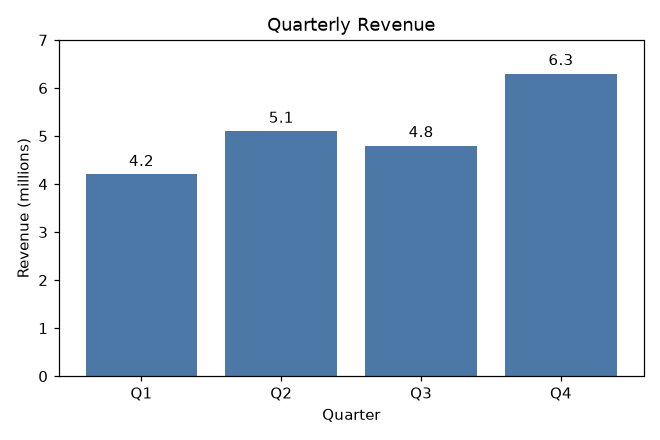

In [27]:
from IPython.display import Image, display

downloaded = sandbox.download_files(["/work/revenue.png"])[0]
print("error :", downloaded.error)
print("bytes :", len(downloaded.content))
print("is PNG:", downloaded.content[:4] == b"\x89PNG")

display(Image(data=downloaded.content))

The same shape produces a PDF or a `.pptx`: the agent writes a script using
`reportlab` or `python-pptx`, the script runs in the sandbox, and
`download_files` returns the bytes. The only change is which package the
allow-list permits and which library the baseline image carries.

---

# Part 8 — A hardened session factory

Everything above, as one function: the thing you would actually call per user
session.

In [28]:
DEFAULT_ALLOWED_HOSTS = ("pypi.org", "files.pythonhosted.org")


def create_session_sandbox(
    session_id,
    *,
    disk_id,
    cpu="1000m",
    memory="2048Mi",
    disk_size=None,
    allowed_hosts=DEFAULT_ALLOWED_HOSTS,
    idle_seconds=300,
):
    """Provision an isolated, capped, network-restricted sandbox for one session."""
    # disk_size must be >= the disk image's own size, so leave it unset to
    # inherit the image's rather than guessing a smaller number and getting a
    # 400 back.
    optional = {"disk_size": disk_size} if disk_size else {}

    client = new_sandbox(
        disk_id=disk_id,
        cpu=cpu,
        memory=memory,
        auto_suspend_seconds=idle_seconds,
        auto_suspend_mode="Memory",
        labels={"nb": "prod-patterns", "session": session_id},
        **optional,
    )

    # Deny first, then allow: the reverse order leaves a window where the
    # sandbox is running with unrestricted egress.
    client.set_egress_default("Deny")
    for host in allowed_hosts:
        client.add_egress_host_rule(host, action="Allow")

    return client


start = time.monotonic()
session = create_session_sandbox("dave", disk_id=image.id)
elapsed = time.monotonic() - start

print(f"provisioned in {elapsed:.2f}s")
print("resources :", session.get().resources)
print("egress    :", session.get_egress_policy().default_action,
      "+", [r.pattern for r in session.get_egress_policy().host_rules])
print("lifecycle :", session.get().lifecycle.auto_suspend)
print("ready     :", session.exec("python -c 'import matplotlib; print(\"ok\")'").stdout.strip())

agent = create_deep_agent(model=model, backend=ACASandbox(session))
print("agent     : ready")

provisioned in 1.73s
resources : SandboxResources(cpu='1000m', memory='2048Mi', disk='20480Mi')
egress    : Deny + ['pypi.org', 'files.pythonhosted.org']


lifecycle : AutoSuspendPolicy(enabled=True, interval=300, mode='Memory')


ready     : ok
agent     : ready


Note the ordering inside the factory: **deny first, then allow.** Creating a
sandbox and configuring egress afterwards leaves a window in which it is running
with open network access. If that window is unacceptable, pass `egress_policy=`
directly to `begin_create_sandbox` so the sandbox is never live without it.

---

# Part 9 — Teardown

Sandboxes, snapshots and disk images all bill until deleted. This removes
everything the notebook registered, keeps going if any single delete fails, and
reports what is left.

In [29]:
for kind, delete in (
    ("sandboxes", group.delete_sandbox),
    ("snapshots", group.delete_snapshot),
    ("images", group.delete_disk_image),
):
    for resource_id in list(CREATED[kind]):
        try:
            delete(resource_id)
            CREATED[kind].remove(resource_id)
        except Exception as exc:  # noqa: BLE001 -- one failure must not stop the rest
            print(f"FAILED to delete {kind[:-1]} {resource_id[:8]}: {exc}")

remaining = {s.id for s in group.list_sandboxes()}
print("sandboxes we created and did not delete:", (remaining - PRE_EXISTING) or "none")
print("snapshots left in group :", [s.id[:8] for s in group.list_snapshots()] or "none")
print("disk images left in group:", [i.id[:8] for i in group.list_disk_images()] or "none")
print("pre-existing, left alone :", len(remaining & PRE_EXISTING))

sandboxes we created and did not delete: none
snapshots left in group : none


disk images left in group: none
pre-existing, left alone : 0


---

# Requirements scorecard

Everything measured in this notebook, against the original list:

| Requirement | Verdict | Evidence |
|---|---|---|
| Cold start ≤ 5s | **Met with room to spare** | ~1s to exec-ready, Part 1 |
| Serverless acceptable | Met | no infrastructure managed here |
| Per-session isolation | **Met** | separate microVMs, Part 2 |
| No cross-user file access | **Met** | Bob cannot see Alice's `/work`, Part 2 |
| Admin-level execution is safe | **Met** | root is scoped to the microVM, Part 2 |
| Network isolation | **Met** | default-deny holds against raw Python, Part 3 |
| Policy control on egress | **Met** | per-host allow rules, Part 3 |
| Memory / compute caps | **Met** | 900MB alloc fails in a 512Mi box, Part 4 |
| Timeouts for runaway code | **Met** | exit 124 at the deadline, Part 4 |
| Preloaded baseline image | **Met** | `commit()` → `disk_id`, Part 5 |
| Dynamic installs | **Met** | pip through the allow-list, Part 5 |
| Whitelist-first packages | **Met** | deny-by-default + allow-list, Part 3/5 |
| Escalation for unlisted packages | **Met** | `get_egress_decisions()` audit, Part 3 |
| Avoid idle waste | **Met** | auto-suspend, ~1s resume, Part 6 |
| Script → artifact pattern | **Met** | agent-authored chart downloaded, Part 7 |

### Not covered here

- **Cosmos / Mongo dashboard connectivity.** The egress allow-list is the
  mechanism — add the database host — but nothing in this notebook connects to a
  real database.
- **VNet integration.** `customer_vnet_connection_name` on
  `begin_create_sandbox` puts sandboxes on your own network; untested here.
- **Volumes.** `create_volume` (Azure Blob, Data Disk) for state that should
  outlive a sandbox rather than travel in its disk image.
- **Public ports.** `add_port` exposes a listener publicly — deliberately left
  out of a sample notebook.
- **NVIDIA Nemotron.** Deferred to a separate notebook.